In [1]:
from model_eval import *

/home/ghope1-swat/EPG-Project/hmc-epg-project/machine-learning/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Optuna Parsing

In [1]:
from __future__ import annotations

import re
import ast
from pathlib import Path
import pandas as pd

LINE_RE = re.compile(
    r"""^outer_fold\s+
        (?P<outer_fold>\d+)\s+
        (?P<timestamp>\d{4}-\d{2}-\d{2}\s+\d{2}:\d{2}:\d{2}\.\d+)\s+
        (?P<trial>\d+)\s+
        (?P<params>\{.*\})\s+
        (?P<macro_f1>[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)\s*$
    """,
    re.VERBOSE,
)

def parse_optuna_log(path: str | Path, expand_params: bool = True) -> pd.DataFrame:
    rows = []
    path = Path(path)

    with path.open("r", encoding="utf-8") as f:
        for line_no, line in enumerate(f, start=1):
            line = line.strip()
            if not line:
                continue

            m = LINE_RE.match(line)
            if not m:
                # Skip unrecognized lines; change to `raise` if you want strict parsing.
                continue

            params_str = m.group("params")
            try:
                params = ast.literal_eval(params_str)  # safe for Python literals
                if not isinstance(params, dict):
                    params = {"_raw_params": params_str}
            except Exception:
                params = {"_raw_params": params_str}

            rows.append(
                {
                    "outer_fold": int(m.group("outer_fold")),
                    "timestamp": pd.to_datetime(m.group("timestamp")),
                    "trial": int(m.group("trial")),
                    "params": params,
                    "macro_f1": float(m.group("macro_f1")),
                    "line_no": line_no,
                }
            )

    df = pd.DataFrame(rows).sort_values(["outer_fold", "trial", "timestamp"]).reset_index(drop=True)

    if expand_params and not df.empty:
        params_df = pd.json_normalize(df["params"])
        # Prefix param columns to avoid name collisions if desired:
        # params_df = params_df.add_prefix("param.")
        df = pd.concat([df.drop(columns=["params"]), params_df], axis=1)

    return df

# Example usage:
# df = parse_optuna_log("optuna.log", expand_params=True)
# print(df.head())


In [2]:
df = parse_optuna_log("unet_crf_optuna.txt", expand_params=True)

In [12]:
from __future__ import annotations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_params_vs_f1(
    df: pd.DataFrame,
    *,
    f1_col: str = "macro_f1",
    fold_col: str = "outer_fold",
    exclude_cols: tuple[str, ...] = ("timestamp", "trial", "line_no"),
    max_cats: int = 30,
    add_lowess: bool = False,
    treat_numeric_as_categorical: tuple[str, ...] = (),
    log_x_cols: tuple[str, ...] = (),
):
    """
    Plot each parameter column vs F1.
      - Numeric params: scatter, colored by fold.
      - Categorical/bool params: boxplot + jittered points colored by fold.
    Options:
      - treat_numeric_as_categorical: numeric columns to plot as categorical
      - log_x_cols: numeric columns to set x-axis to log scale
    """

    # Optional LOWESS smoothing line (overall, not per fold)
    if add_lowess:
        try:
            from statsmodels.nonparametric.smoothers_lowess import lowess
        except Exception:
            lowess = None
            add_lowess = False
    else:
        lowess = None

    required = {f1_col, fold_col}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Missing columns in df: {sorted(missing)}")

    # Candidate parameter columns: everything except f1/fold + excludes
    exclude = set(exclude_cols) | {f1_col, fold_col}
    param_cols = [c for c in df.columns if c not in exclude]

    folds = [f for f in sorted(df[fold_col].dropna().unique())]

    def is_numeric_series(s: pd.Series) -> bool:
        return pd.api.types.is_numeric_dtype(s) and not pd.api.types.is_bool_dtype(s)

    def is_bool_series(s: pd.Series) -> bool:
        return pd.api.types.is_bool_dtype(s)

    plots_made = 0

    for col in param_cols:
        if col not in df.columns:
            continue

        x_all = df[col]
        y_all = df[f1_col]
        fold_all = df[fold_col]

        # Drop rows missing x/y/fold (for coloring)
        mask = x_all.notna() & y_all.notna() & fold_all.notna()
        if not mask.any():
            continue

        x_all = x_all[mask]
        y_all = y_all[mask]
        fold_all = fold_all[mask]

        # Skip constant columns
        if x_all.nunique(dropna=True) <= 1:
            continue

        force_cat = col in set(treat_numeric_as_categorical)

        # --- CATEGORICAL PATH ---
        if is_bool_series(x_all) or (not is_numeric_series(x_all)) or force_cat:
            # cast to strings for category labels
            cat = x_all.astype(str)

            # Too many categories -> keep top-k by count, collapse the rest
            if cat.nunique() > max_cats:
                top = cat.value_counts().head(max_cats).index
                cat = cat.where(cat.isin(top), other="__OTHER__")

            tmp = pd.DataFrame({fold_col: fold_all, "cat": cat, f1_col: y_all})

            # Order categories by median F1 (overall)
            order = (
                tmp.groupby("cat")[f1_col]
                .median()
                .sort_values(ascending=False)
                .index
                .tolist()
            )
            pos = {k: i + 1 for i, k in enumerate(order)}  # 1-based for boxplot

            plt.figure(figsize=(max(6, 0.35 * len(order) + 2), 4.5))

            # Boxplot (overall distribution per category)
            data = [tmp.loc[tmp["cat"] == k, f1_col].values for k in order]
            plt.boxplot(data, labels=order, showfliers=False)

            # Jittered points colored by fold
            rng = np.random.default_rng(0)
            for f in folds:
                sub = tmp[tmp[fold_col] == f]
                if sub.empty:
                    continue
                xs = np.array([pos[c] for c in sub["cat"].values], dtype=float)
                xs = xs + rng.normal(0.0, 0.06, size=len(xs))
                plt.scatter(xs, sub[f1_col].values, c='steelblue', alpha=0.5, s=14, label=f"{fold_col} {f}")

            plt.xticks(rotation=45, ha="right")
            plt.xlabel(col)
            plt.ylabel(f1_col)
            plt.title(f"{col} vs {f1_col} (colored by {fold_col})")
            plt.legend(title=fold_col, bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0.0)
            plt.tight_layout()
            plots_made += 1
            continue

        # --- NUMERIC PATH ---
        plt.figure()

        # Handle log-x option
        logx = col in set(log_x_cols)
        if logx:
            # log scale requires x > 0
            pos_mask = x_all.astype(float) > 0
            if not pos_mask.any():
                print(f"[warn] {col}: requested log x-scale but no x > 0; skipping plot.")
                plt.close()
                continue
            if (~pos_mask).any():
                print(f"[warn] {col}: dropping {(~pos_mask).sum()} non-positive rows for log x-scale.")
            x_all2 = x_all[pos_mask].astype(float)
            y_all2 = y_all[pos_mask].astype(float)
            fold_all2 = fold_all[pos_mask]
        else:
            x_all2 = x_all.astype(float)
            y_all2 = y_all.astype(float)
            fold_all2 = fold_all

        # Scatter by fold (uses matplotlib default color cycle)
        for f in folds:
            m = fold_all2 == f
            if not m.any():
                continue
            plt.scatter(x_all2[m].values, y_all2[m].values, c='steelblue', alpha=0.5, label=f"{fold_col} {f}")

        if logx:
            plt.xscale("log")

        # Optional LOWESS (overall trend, ignoring folds)
        if add_lowess and lowess is not None and len(x_all2) >= 20:
            xx = x_all2.values
            yy = y_all2.values
            order = np.argsort(xx)
            sm = lowess(yy[order], xx[order], frac=0.35, return_sorted=True)
            plt.plot(sm[:, 0], sm[:, 1], linewidth=2)

        plt.xlabel(col)
        plt.ylabel(f1_col)
        title = f"{col} vs {f1_col} (colored by {fold_col})"
        if logx:
            title += " [log x]"
        plt.title(title)
        plt.legend(title=fold_col, bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0.0)
        plt.tight_layout()
        plots_made += 1

    if plots_made == 0:
        print("No parameter plots were produced (no varying parameter columns found).")


/tmp/ipykernel_363890/2872914995.py:105: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=order, showfliers=False)
/tmp/ipykernel_363890/2872914995.py:105: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=order, showfliers=False)
/tmp/ipykernel_363890/2872914995.py:105: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=order, showfliers=False)
/tmp/ipykernel_363890/2872914995.py:105: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  pl

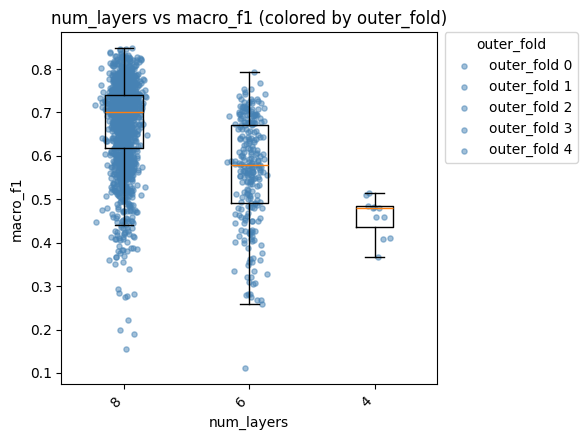

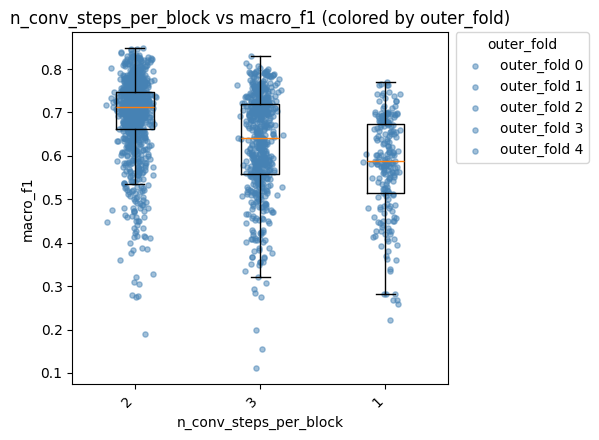

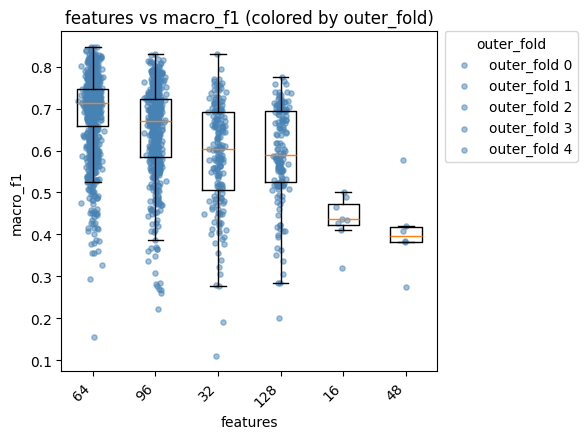

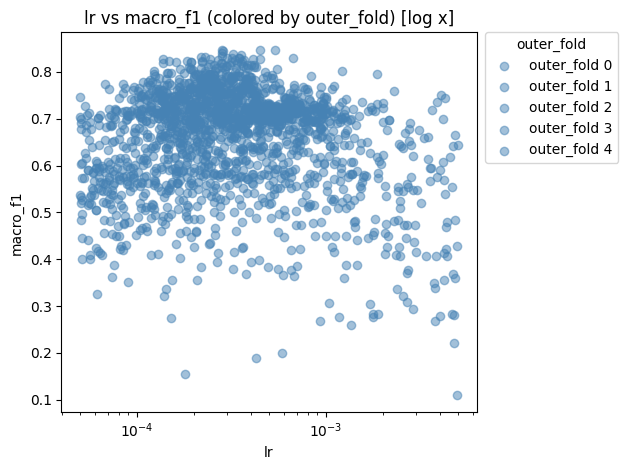

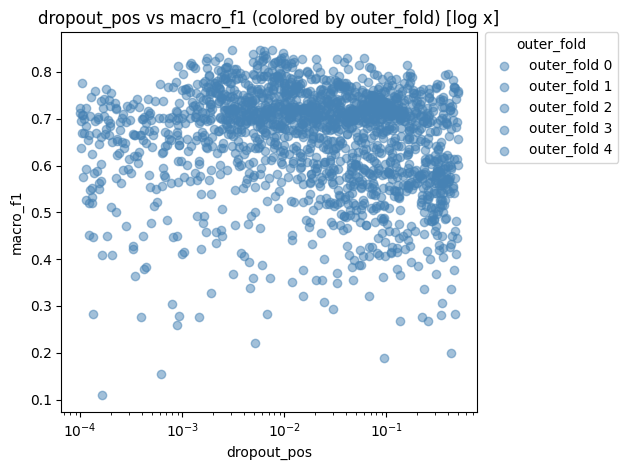

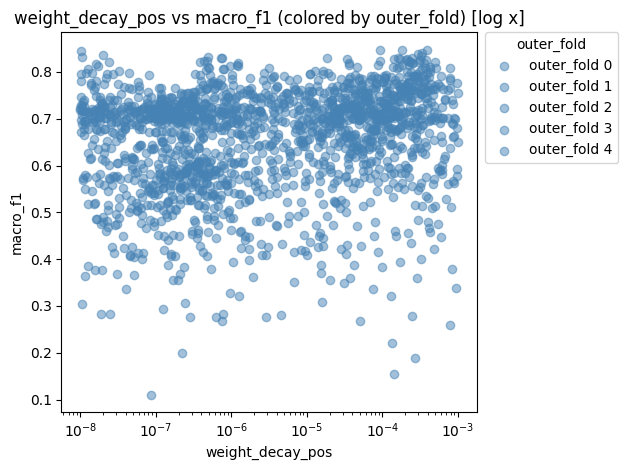

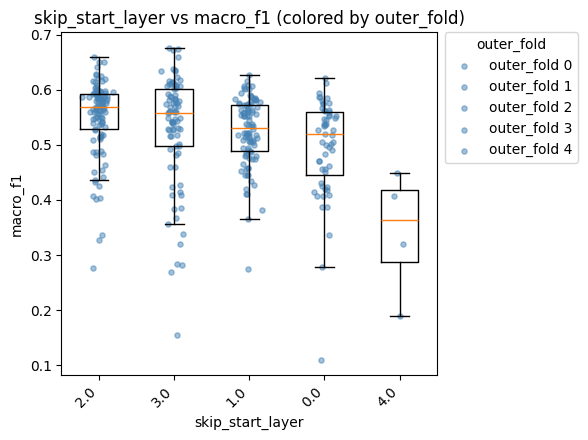

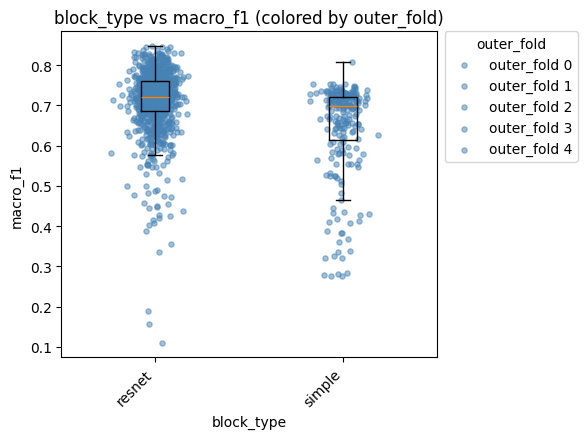

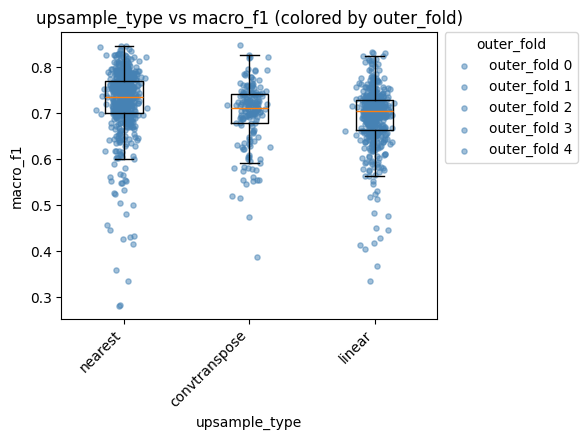

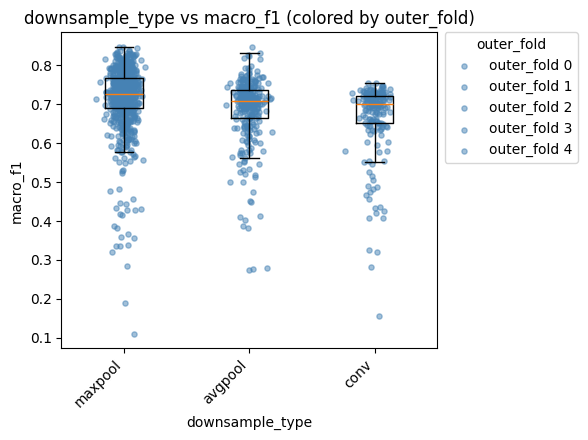

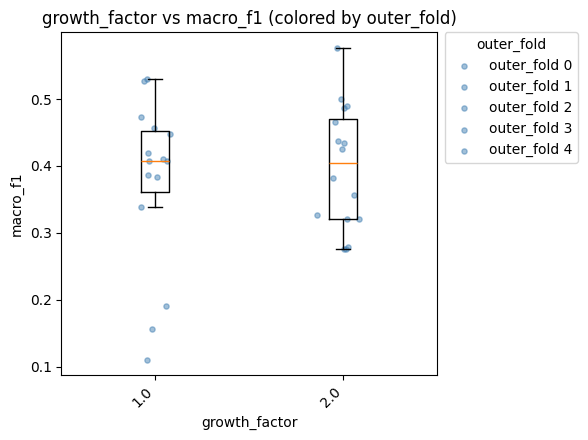

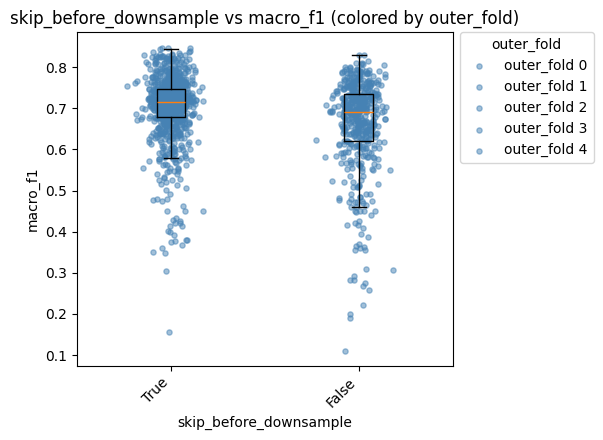

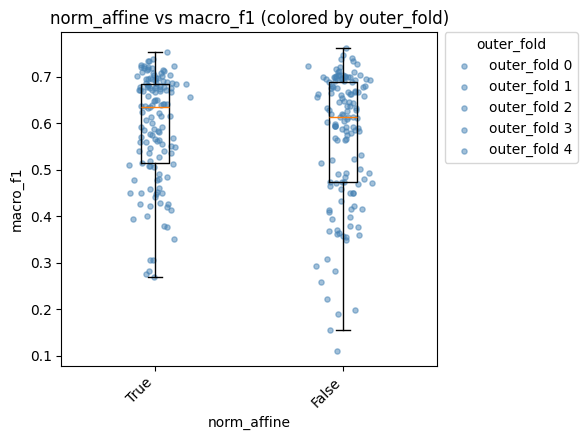

In [13]:
df = df[df['timestamp'] > '2026-02-09']
plot_params_vs_f1(df, treat_numeric_as_categorical=['num_layers', 'n_conv_steps_per_block', 'features', 'skip_start_layer', 'growth_factor'],
                   log_x_cols=['lr', 'dropout_pos', 'weight_decay_pos'])

# Consolidating experiments

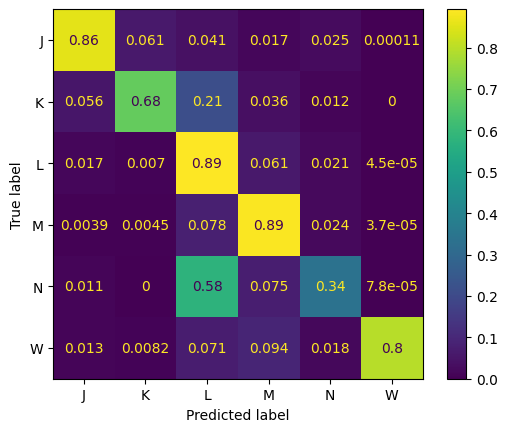

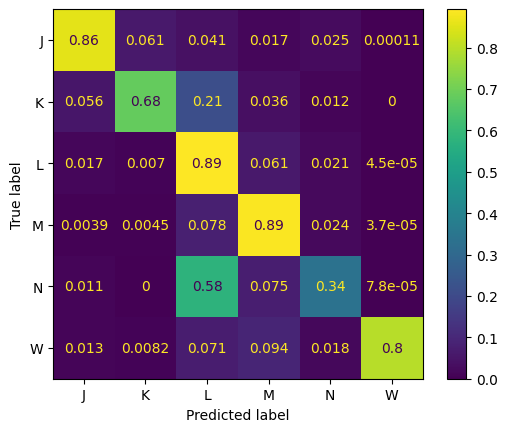

In [3]:
MODEL_DIR = "vnested_model_evaluation_unet_crf"
MODEL_NAME = "unet_crf"

labels_true, labels_pred = [], []
for fold in range(5):
    model_path = f"results/{MODEL_DIR}/fold_{fold}/{MODEL_NAME}_allpredictions.csv"
    df = pd.read_csv(model_path)
    labels_true.extend(df["labels_true"].tolist())
    labels_pred.extend(df["labels_pred"].tolist())

# Calculate statistics across every dataset
labels = sorted(np.unique(labels_true))
all_precision, all_recall, all_fscore, _ = precision_recall_fscore_support(labels_true, labels_pred, 
                                                        labels=labels, average = None, zero_division=0)
temp_dict = {"precision" : all_precision, 
                "recall" : all_recall, 
                "fscore" : all_fscore}
out_dataframe = pd.DataFrame(temp_dict, index=labels).stack()
out_dataframe.index = out_dataframe.index.map('{0[1]}_{0[0]}'.format)
out_dataframe = out_dataframe.to_frame().T
out_dataframe["accuracy"] = accuracy_score(labels_true, labels_pred)
all_precision_micro, all_recall_micro, all_fscore_micro, _ = precision_recall_fscore_support(labels_true, labels_pred, 
                                                        labels=labels, average = "micro", zero_division=0)
all_precision_macro, all_recall_macro, all_fscore_macro, _ = precision_recall_fscore_support(labels_true, labels_pred, 
                                                        labels=labels, average = "macro", zero_division=0)
out_dataframe["precision_micro"] = all_precision_micro
out_dataframe["recall_micro"] = all_recall_micro
out_dataframe["fscore_micro"] = all_fscore_micro
out_dataframe["precision_macro"] = all_precision_macro
out_dataframe["recall_macro"] = all_recall_macro
out_dataframe["fscore_macro"] = all_fscore_macro
os.makedirs(f"results/{MODEL_DIR}/summary_stats", exist_ok=True)
out_dataframe.to_csv(f"results/{MODEL_DIR}/summary_stats/{MODEL_NAME}_SummaryStats.csv")

overall = ConfusionMatrixDisplay.from_predictions(labels_true, labels_pred, \
                                        normalize = 'true')
overall.plot().figure_.savefig(rf"results/{MODEL_DIR}/summary_stats/{MODEL_NAME}_OverallConfusionMatrix.png")
all_data = pd.DataFrame({'labels_true': labels_true,
                            'labels_pred': labels_pred})
all_data.to_csv(f"results/{MODEL_DIR}/summary_stats/{MODEL_NAME}_allpredictions.csv")

In [2]:
def generate_roc(test_data, all_logits, save_path=None, model_name=None, fold=None):
    lw = 3
    import numpy as np
    import matplotlib.pyplot as plt
    from itertools import cycle

    from sklearn import svm, datasets
    from sklearn.metrics import roc_curve, auc, precision_recall_curve
    from sklearn.model_selection import train_test_split
    from sklearn.preprocessing import label_binarize
    from sklearn.multiclass import OneVsRestClassifier
    from sklearn.metrics import roc_auc_score
    labels_true = []
    logit_dfs = []
    labels = ["J", "K", "L", "M", "N", "W"]
    for df, logits in zip(test_data, all_logits):
        labels_true.extend(df["labels"].values)
        logit_dfs.append(pd.DataFrame(logits, columns=labels))

    logits = pd.concat(logit_dfs).reset_index(drop=True)
    label_map = {
                "J"  : 0,
                "K"  : 1,
                "L"  : 2,
                "M"  : 3,
                "N"  : 4,
                "W"  : 5
            }
    label_to_color = {
            "NP": "red",
            "J": "blue",
            "K": "green",
            "L": "purple",
            "M": "pink",
            "N": "cyan",
            "W": "orange"
    }
    
    from sklearn.preprocessing import OneHotEncoder
    true_labels = pd.DataFrame(data=OneHotEncoder(categories=[labels]).fit_transform(np.array(labels_true).reshape(-1, 1)).toarray(), columns = labels)
    y_test = true_labels.values
    y_score = logits.values
    # Compute ROC curve and ROC area for each class
    fpr = dict()
    tpr = dict()
    precision = dict()
    recall = dict()
    roc_auc = dict()
    pr_auc = dict()
    n_classes = y_test.shape[1]
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_test[:, i], y_score[:, i])
        precision[i], recall[i], _ = precision_recall_curve(y_test[:, i], y_score[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
        pr_auc[i] = auc(recall[i], precision[i])

    # Compute micro-average ROC curve and ROC area
    fpr["micro"], tpr["micro"], _ = roc_curve(y_test.ravel(), y_score.ravel())
    precision["micro"], recall["micro"], _ = precision_recall_curve(y_test.ravel(), y_score.ravel())
    roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])
    pr_auc["micro"] = auc(recall["micro"], precision["micro"])
    # First aggregate all false positive rates
    all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
    all_recall = np.unique(np.concatenate([recall[i] for i in range(n_classes)]))


    # Then interpolate all ROC curves at this points
    mean_tpr = np.zeros_like(all_fpr)
    for i in range(n_classes):
        mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
    mean_precision = np.zeros_like(all_recall)
    for i in range(n_classes):
        mean_precision += np.interp(all_recall, recall[i], precision[i])

    # Finally average it and compute AUC
    mean_tpr /= n_classes
    mean_precision /= n_classes

    fpr["macro"] = all_fpr
    tpr["macro"] = mean_tpr
    roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])
    recall["macro"] = all_recall
    precision["macro"] = mean_precision
    pr_auc["macro"] = auc(recall["macro"], precision["macro"])

    # Plot all ROC curves
    plt.figure()
    plt.plot(
        fpr["micro"],
        tpr["micro"],
        label="micro-average ROC curve (area = {0:0.2f})".format(roc_auc["micro"]),
        color="deeppink",
        linestyle=":",
        linewidth=lw,
    )

    plt.plot(
        fpr["macro"],
        tpr["macro"],
        label="macro-average ROC curve (area = {0:0.2f})".format(roc_auc["macro"]),
        color="navy",
        linestyle=":",
        linewidth=lw,
    )

    for i, label in enumerate(labels):
        plt.plot(
            fpr[i],
            tpr[i],
            color=label_to_color[label],
            lw=lw,
            label="ROC curve of class {0} (area = {1:0.2f})".format(label, roc_auc[i]),
        )

    plt.plot([0, 1], [0, 1], "k--", lw=2)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC curve")
    plt.legend(loc="lower right")
    plt.savefig(rf"{save_path}/{model_name}_ROC_Fold{fold}.png")

    # Plot all PR curves
    plt.figure()
    plt.plot(
        recall["micro"],
        precision["micro"],
        label="micro-average PR curve (area = {0:0.2f})".format(pr_auc["micro"]),
        color="deeppink",
        linestyle=":",
        linewidth=lw,
    )

    plt.plot(
        recall["macro"],
        precision["macro"],
        label="macro-average PR curve (area = {0:0.2f})".format(pr_auc["macro"]),
        color="navy",
        linestyle=":",
        linewidth=lw,
    )

    for i, label in enumerate(labels):
        plt.plot(
            recall[i],
            precision[i],
            color=label_to_color[label],
            lw=lw,
            label="PR curve of class {0} (area = {1:0.2f})".format(label, pr_auc[i]),
        )

    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision-Recall curve")
    plt.legend(loc="lower right")
    plt.savefig(rf"{save_path}/{model_name}_PR_Fold{fold}.png")


In [ ]:
parser = argparse.ArgumentParser(
    prog = "Model Performance Evaluator",
    description = "This program takes in EPG data and a \
                    labeler program, trains it, and then \
                    generates statistics and figures to \
                    characterize the model's performance."
)
parser.add_argument("--data_path", type = str, required = True)
parser.add_argument("--model_path", type = str, required = True)
parser.add_argument("--save_path", type = str, required = True)
parser.add_argument("--model_name", type = str, required = True)
parser.add_argument("--augment", action="store_true")
parser.add_argument("--post_process", type = str, required = False) # can either be s/smooth or viterbi/m
parser.add_argument("--epochs", type = int, required=False)
parser.add_argument("--optuna", action="store_true")
parser.add_argument("--attention", action="store_true") # can only be used with UNet 
args = parser.parse_args('--attention --data_path /data/labs/hopelab/epg/tarsalis_data_clean --model_path unet.py --save_path ./model_outputs --model_name unet_test'.split())

print("Loading Data...")
data = DataImport(args.data_path, 5)

summary_data = []
labels_true = []
labels_pred = []
logits_pred = []
all_test = []
for fold, (train_index, test_index) in enumerate(data.cross_val_iter):
    print(f"Evaluating Fold {fold}")
    train_data = [data.raw_dfs[i] for i in train_index]
    test_data = [data.raw_dfs[i] for i in test_index]
    train_data, _ = data.get_probes(train_data)
    test_data, test_names = data.get_probes(test_data)

    if args.augment:
        augmented_train_data = build_augmented_dataset(train_data, 10)
        print(f"{len(augmented_train_data)} Training Probes with Augment")
    
    model_import = dynamic_importer(args.model_path)
    
    kwargs = dict()
    if args.model_path == "unet.py":
        if args.attention:
            # expected f1: 0.7402015172114621
            kwargs['bottleneck_type'] = 'windowed_attention'
            kwargs = kwargs | {'epochs': 64, 'lr': 0.0005, 'dropout_rate': 1e-05, 'weight_decay': 1e-06, 'num_layers': 8, 'features': 32, 'transformer_window_size': 150, 'transformer_layers': 2}
            heads_per_channel = 32
            kwargs['transformer_nhead'] = max(kwargs['features'] // heads_per_channel, 1)
            kwargs['embed_dim'] = kwargs['features']
        else:
            # expected f1: 0.694895
            kwargs['bottleneck_type'] = 'block'
            kwargs = kwargs | {'epochs': 64, 'lr': 0.0005, 'dropout_rate': 0.1, 'weight_decay': 1e-06, 'num_layers': 8, 'features': 32}

        if args.epochs:
            kwargs['epochs'] = args.epochs

    kwargs['loss_gamma'] = 2.0
    model = model_import.Model(save_path = args.save_path, **kwargs)
    print("Training Model...")
    
    if args.augment:
        final_train_data = augmented_train_data
    else:
        final_train_data = train_data
    print(final_train_data[0].columns)
    model.train(final_train_data, test_data, fold, show_train_curve=True)
        
    print("Evaluating Model...")
    
    if args.post_process is None:
        predicted_labels = model.predict(test_data)

    elif args.post_process.lower() == "viterbi" or args.post_process.lower() == "v":
        _, logits = model.predict(test_data, return_logits=True)
        logits = [l.squeeze(0).detach().numpy() for l in logits]
        post_process = PostProcessor(train_data, model.inv_label_map)
        predicted_labels = [post_process.postprocess_viterbi(logit) for logit in logits]

    elif args.post_process.lower() == "smooth" or args.post_process.lower() == "s":
        _, logits = model.predict(test_data, return_logits=True)
        post_process = PostProcessor(train_data, model.inv_label_map)
        predicted_labels = [post_process.postprocess_smooth(logit.squeeze(0).detach().numpy()) for logit in logits]
    elif args.post_process.lower() == "smooth" or args.post_process.lower() == "s":
        _, logits = model.predict(test_data, return_logits=True)
        logits = [l.squeeze(0).detach().numpy() for l in logits]
        post_process = PostProcessor(train_data, model.inv_label_map)
        predicted_labels = [post_process.postprocess_smooth(logit) for logit in logits]
    else:
        print("Choose a valid (case insensitive) post-processing arguement: either V/Viterbi or S/Smooth. Terminating program")
        assert False #TODO: make this better
        
    print("Generating Report...")
    true, pred, stats = generate_report(test_data, predicted_labels, test_names, args.save_path, args.model_name, fold)
    summary_data.append(stats)
    labels_true.extend(true)
    labels_pred.extend(pred)

    _, logits = model.predict(test_data, return_logits=True)
    logits_pred.extend([l.permute(2, 0, 1).squeeze(1).detach().numpy() for l in logits])
    all_test.extend(test_data)
    generate_roc(test_data, [l.permute(2, 0, 1).squeeze(1).detach().numpy() for l in logits], args.save_path, args.model_name, fold)
    
out_summary_data = pd.concat(summary_data)

# Calculate statistics across every dataset
labels = sorted(np.unique(labels_true))
all_precision, all_recall, all_fscore, _ = precision_recall_fscore_support(labels_true, labels_pred, 
                                                        labels=labels, average = None, zero_division=0)
temp_dict = {"precision" : all_precision, 
                "recall" : all_recall, 
                "fscore" : all_fscore}
out_dataframe = pd.DataFrame(temp_dict, index=labels).stack()
out_dataframe.index = out_dataframe.index.map('{0[1]}_{0[0]}'.format)
out_dataframe = out_dataframe.to_frame().T
out_dataframe["accuracy"] = accuracy_score(labels_true, labels_pred)

out_summary_data = pd.concat([out_summary_data, out_dataframe])
out_summary_data.to_csv(f"{args.save_path}/{args.model_name}_SummaryStats.csv")

overall = ConfusionMatrixDisplay.from_predictions(labels_true, labels_pred, \
                                        normalize = 'true')
overall.plot().figure_.savefig(rf"{args.save_path}/{args.model_name}_OverallConfusionMatrix.png")

all_data = pd.DataFrame({'labels_true': labels_true,
                            'labels_pred': labels_pred})
all_data.to_csv(f"{args.save_path}/{args.model_name}_allpredictions.csv")

generate_roc(all_test, logits_pred, args.save_path, args.model_name, "Overall")

Loading Data...
Evaluating Fold 0


KeyboardInterrupt: 

In [ ]:
def generate_roc(
    test_data,
    all_logits,
    save_path=None,
    model_name="model",
    fold=0,
    labels=("J","K","L","M","N","W"),
    class_colors=None,
    score_transform="identity",  # "identity", "sigmoid", or "softmax"
    mark_argmax_operating_point=True,
    point_size=80,
):
    import os
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    from sklearn.metrics import roc_curve, auc, precision_recall_curve
    from sklearn.preprocessing import label_binarize

    # Color map
    default_colors = {
        "J": "blue", "K": "green", "L": "purple",
        "M": "pink", "N": "cyan", "W": "orange"
    }
    label_to_color = default_colors if class_colors is None else class_colors

    # ---- collect y and scores ----
    y_true_labels = []
    score_frames = []
    for df, logits in zip(test_data, all_logits):
        y_true_labels.extend(df["labels"].astype(str).values)
        score_frames.append(pd.DataFrame(logits, columns=labels))
    scores = pd.concat(score_frames, ignore_index=True).astype(float)  # shape [N, C]

    # ---- score transforms ----
    if score_transform == "sigmoid":
        x = scores.values
        scores = pd.DataFrame(1.0 / (1.0 + np.exp(-x)), columns=labels)
    elif score_transform == "softmax":
        x = scores.values
        x = x - x.max(axis=1, keepdims=True)         # numerical stability
        ex = np.exp(x)
        scores = pd.DataFrame(ex / ex.sum(axis=1, keepdims=True), columns=labels)
    # else: identity (raw logits)

    # ---- binarize y (OvR) ----
    y_test = label_binarize(y_true_labels, classes=list(labels))  # shape [N, C]
    y_score = scores.values
    n_classes = y_test.shape[1]
    N = y_score.shape[0]

    # ---- per-class curves ----
    fpr, tpr, roc_auc = {}, {}, {}
    precision, recall, pr_auc = {}, {}, {}

    valid_class_idx = []
    for i in range(n_classes):
        # need at least one positive and one negative to compute curve
        has_pos = (y_test[:, i].sum() > 0)
        has_neg = ((1 - y_test[:, i]).sum() > 0)
        if not (has_pos and has_neg):
            continue
        valid_class_idx.append(i)

        fpr[i], tpr[i], _ = roc_curve(y_test[:, i], y_score[:, i])
        precision[i], recall[i], _ = precision_recall_curve(y_test[:, i], y_score[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
        pr_auc[i] = auc(recall[i], precision[i])

    # ---- micro averages ----
    if len(valid_class_idx) > 0:
        fpr["micro"], tpr["micro"], _ = roc_curve(y_test[:, valid_class_idx].ravel(),
                                                  y_score[:, valid_class_idx].ravel())
        precision["micro"], recall["micro"], _ = precision_recall_curve(
            y_test[:, valid_class_idx].ravel(), y_score[:, valid_class_idx].ravel()
        )
        roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])
        pr_auc["micro"] = auc(recall["micro"], precision["micro"])

        # ---- macro averages (simple interpolation) ----
        all_fpr = np.unique(np.concatenate([fpr[i] for i in valid_class_idx]))
        mean_tpr = np.zeros_like(all_fpr)
        for i in valid_class_idx:
            mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
        mean_tpr /= len(valid_class_idx)
        fpr["macro"], tpr["macro"] = all_fpr, mean_tpr
        roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

        all_recall = np.unique(np.concatenate([recall[i] for i in valid_class_idx]))
        mean_precision = np.zeros_like(all_recall)
        for i in valid_class_idx:
            mean_precision += np.interp(all_recall, recall[i], precision[i])
        mean_precision /= len(valid_class_idx)
        recall["macro"], precision["macro"] = all_recall, mean_precision
        pr_auc["macro"] = auc(recall["macro"], precision["macro"])

    # ---- default argmax operating point (per class) ----
    # This is the discrete classifier that predicts argmax across classes.
    # For each class i, compute its OvR confusion stats under argmax.
    argmax_idx = y_score.argmax(axis=1)  # predicted class per sample
    op_points = {}  # i -> dict with fpr,tpr,prec,recall,f1
    for i in range(n_classes):
        y_true_i = (y_test[:, i] == 1)
        y_pred_i = (argmax_idx == i)

        tp = np.sum(y_pred_i & y_true_i)
        fp = np.sum(y_pred_i & (~y_true_i))
        fn = np.sum((~y_pred_i) & y_true_i)
        tn = N - tp - fp - fn

        # metrics with safe division
        tpr_i = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        fpr_i = fp / (fp + tn) if (fp + tn) > 0 else 0.0
        prec_i = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        rec_i = tpr_i
        f1_i = (2 * prec_i * rec_i / (prec_i + rec_i)) if (prec_i + rec_i) > 0 else 0.0
        op_points[i] = dict(fpr=fpr_i, tpr=tpr_i, prec=prec_i, rec=rec_i, f1=f1_i)

    # ---- ensure output dir ----
    if save_path is not None:
        os.makedirs(save_path, exist_ok=True)

    lw = 3

    # ===================== ROC plot =====================
    plt.figure()
    if "micro" in fpr:
        plt.plot(fpr["micro"], tpr["micro"],
                 label=f"micro-average ROC (AUC = {roc_auc['micro']:.2f})",
                 linestyle=":", linewidth=lw, color="deeppink")
    if "macro" in fpr:
        plt.plot(fpr["macro"], tpr["macro"],
                 label=f"macro-average ROC (AUC = {roc_auc['macro']:.2f})",
                 linestyle=":", linewidth=lw, color="navy")

    for i, lab in enumerate(labels):
        if i in valid_class_idx:
            plt.plot(fpr[i], tpr[i], label=f"{lab} (AUC = {roc_auc[i]:.2f})",
                     lw=lw, color=label_to_color.get(lab, None))

        if mark_argmax_operating_point:
            pt = op_points[i]
            plt.scatter(pt["fpr"], pt["tpr"], s=point_size,
                        edgecolor="k", linewidths=0.7,
                        color=label_to_color.get(lab, None), alpha=0.9,
                        label=None)
            # Annotate with F1 near the point
            plt.annotate(f"F1={pt['f1']:.2f}", (pt["fpr"], pt["tpr"]),
                         xytext=(5, -10), textcoords="offset points", fontsize=8)

    plt.plot([0, 1], [0, 1], "k--", lw=2)
    plt.xlim(0, 1); plt.ylim(0, 1.05)
    plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
    plt.title("ROC curves")
    plt.legend(loc="lower right", ncol=2, fontsize=8)
    if save_path is not None:
        plt.tight_layout()
        plt.savefig(os.path.join(save_path, f"{model_name}_ROC_Fold{fold}.png"), dpi=200)
        plt.close()
    else:
        plt.show()

    # ===================== PR plot =====================
    plt.figure()
    if "micro" in precision:
        plt.plot(recall["micro"], precision["micro"],
                 label=f"micro-average PR (AUC = {pr_auc['micro']:.2f})",
                 linestyle=":", linewidth=lw, color="deeppink")
    if "macro" in precision:
        plt.plot(recall["macro"], precision["macro"],
                 label=f"macro-average PR (AUC = {pr_auc['macro']:.2f})",
                 linestyle=":", linewidth=lw, color="navy")

    for i, lab in enumerate(labels):
        if i in valid_class_idx:
            plt.plot(recall[i], precision[i], label=f"{lab} (AUC = {pr_auc[i]:.2f})",
                     lw=lw, color=label_to_color.get(lab, None))

        if mark_argmax_operating_point:
            pt = op_points[i]
            plt.scatter(pt["rec"], pt["prec"], s=point_size,
                        edgecolor="k", linewidths=0.7,
                        color=label_to_color.get(lab, None), alpha=0.9,
                        label=None)
            plt.annotate(f"F1={pt['f1']:.2f}", (pt["rec"], pt["prec"]),
                         xytext=(5, -10), textcoords="offset points", fontsize=8)

    plt.xlim(0, 1); plt.ylim(0, 1.05)
    plt.xlabel("Recall"); plt.ylabel("Precision")
    plt.title("Precision–Recall curves")
    plt.legend(loc="lower left", ncol=2, fontsize=8)
    if save_path is not None:
        plt.tight_layout()
        plt.savefig(os.path.join(save_path, f"{model_name}_PR_Fold{fold}.png"), dpi=200)
        plt.close()
    else:
        plt.show()


In [11]:
generate_roc(all_test, logits_pred, args.save_path, args.model_name, "Overall")

In [ ]:
di = DataImport('/data/labs/hopelab/epg/tarsalis_data_clean', 2)
data = di.import_data('/data/labs/hopelab/epg/tarsalis_data_clean')[0]
data = di.get_probes(data)
all_labels = pd.concat([d for d in data[0]])
labelnames = dict(W='Withdrawal', J='Pre-probing', K='Penetration', N='Unknown', L='Search for vessel', M='Ingestion')
labels, counts = np.unique(all_labels['labels'], return_counts=True)
fracs = counts / counts.sum()
percents = fracs * 100
percents 
chunks = dict()
for label in all_labels['labels'].unique():
    lchunk = all_labels[all_labels['labels'] == label]
    non_sequence = pd.Series(lchunk.index).diff() != 1
    grouper = non_sequence.cumsum().values

    # Split the DataFrame using groupby
    dfs = [dfx for _, dfx in lchunk.groupby(grouper)]
    chunks[label] = dfs

NameError: name 'chunks' is not defined

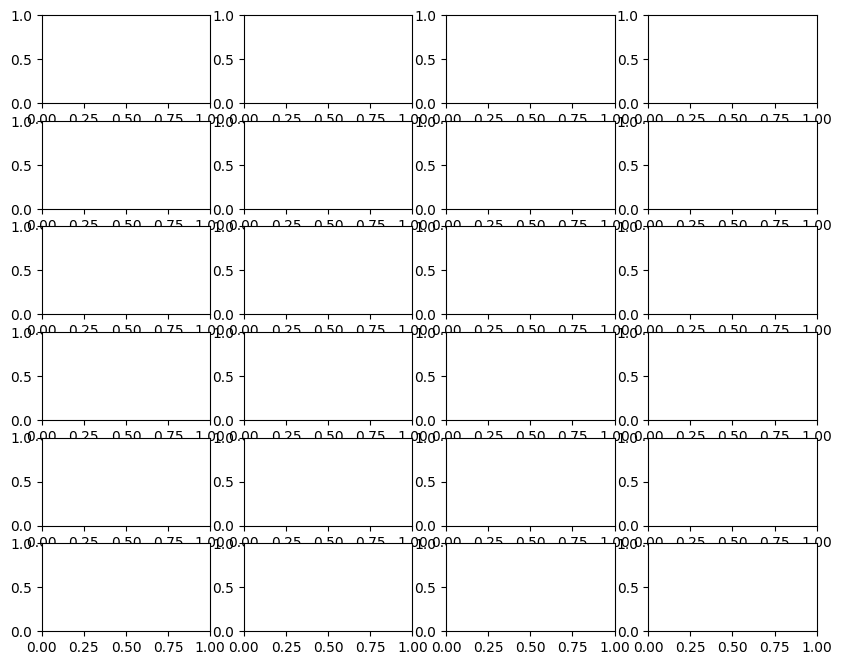

In [8]:

import seaborn as sns
fig, axs = plt.subplots(6, 4, figsize=(10, 8))
for ax, label in zip(axs, chunks.keys()):
    ax[0].axis('off')
    for i in range(1, 4):
        seq = chunks[label][np.random.randint(0, len(chunks[label]))]['post_rect'][:300]
        ax[i].plot(seq.values)
        if label == 'W':
            ax[i].set_xlabel('Time (ms)')
        ax[i].set_title(labelnames[label])
        if i == 1:
            ax[i].set_ylabel('Voltage (V)')
sns.despine()
plt.tight_layout()
plt.show()

In [11]:
labelcolors = {'W': 'F8D38B', 'J': '7F7FF7', 'K': '8EBD86', 'N': 'A0FCFE', 'L': 'B682BB', 'M': 'FAE0E4'}

ValueError: Calling nonzero on 0d arrays is not allowed. Use np.atleast_1d(scalar).nonzero() instead. If the context of this error is of the form `arr[nonzero(cond)]`, just use `arr[cond]`.

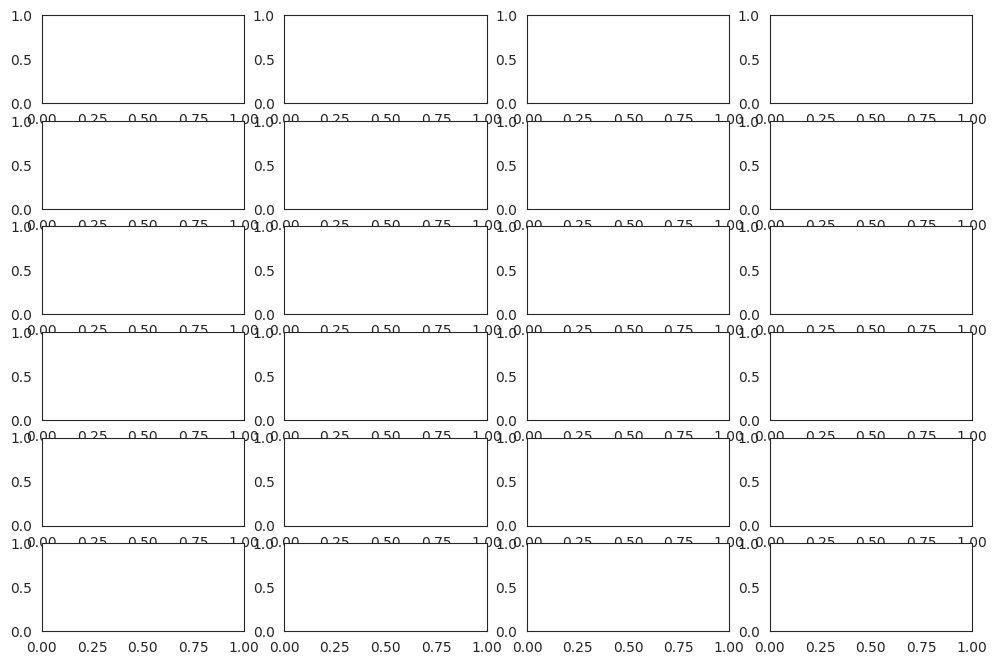

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("white")
import numpy as np

fig, axs = plt.subplots(6, 4, figsize=(12, 8))

for ax_row, label in zip(axs, chunks.keys()):
    # Use the first column for the row label
    ax_row[0].text(0.5, 0.5, labelnames[label] + ' ({})'.format(label) + '\n({:.2f}%)'.format(percents[np.where(labels == label)[0][0]]),
                   transform=ax_row[0].transAxes,
                   rotation=0,
                   va='center', ha='center', fontsize=12, weight='bold')
    ax_row[0].axis('off')  # hide frame and ticks

    # Plot the actual data in columns 1–3
    for i in range(1, 4):
        seq = chunks[label][np.random.randint(0, len(chunks[label]))]['post_rect'][:300]
        ax_row[i].plot(seq.values, color='black')
        ax_row[i].set_facecolor('#' + labelcolors[label])
        if label == 'W':
            ax_row[i].set_xlabel('Time (s)')
        ax_row[i].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: '{:.1f}'.format(x / 100)))
        if i == 1:
            ax_row[i].set_ylabel('Voltage (V)')
            ax_row[i].yaxis.set_label_coords(-0.2, 0.5)
            ax_row[i].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: '{:.2f}'.format(x)))

sns.despine()
plt.tight_layout()
plt.savefig('tarsalis_epg_behavior_examples.pdf')
plt.show()


In [13]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import cycle

from sklearn import svm, datasets
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import roc_auc_score

# Import some data to play with
iris = datasets.load_iris()
X = iris.data
y = iris.target

# Binarize the output
y = label_binarize(y, classes=[0, 1, 2])
n_classes = y.shape[1]

# Add noisy features to make the problem harder
random_state = np.random.RandomState(0)
n_samples, n_features = X.shape
X = np.c_[X, random_state.randn(n_samples, 200 * n_features)]

# shuffle and split training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=0)

# Learn to predict each class against the other
classifier = OneVsRestClassifier(
    svm.SVC(kernel="linear", probability=True, random_state=random_state)
)
y_score = classifier.fit(X_train, y_train).decision_function(X_test)

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Compute micro-average ROC curve and ROC area
fpr["micro"], tpr["micro"], _ = roc_curve(y_test.ravel(), y_score.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

In [14]:
y_test

array([[0, 0, 1],
       [0, 1, 0],
       [1, 0, 0],
       [0, 0, 1],
       [1, 0, 0],
       [0, 0, 1],
       [1, 0, 0],
       [0, 1, 0],
       [0, 1, 0],
       [0, 1, 0],
       [0, 0, 1],
       [0, 1, 0],
       [0, 1, 0],
       [0, 1, 0],
       [0, 1, 0],
       [1, 0, 0],
       [0, 1, 0],
       [0, 1, 0],
       [1, 0, 0],
       [1, 0, 0],
       [0, 0, 1],
       [0, 1, 0],
       [1, 0, 0],
       [1, 0, 0],
       [0, 0, 1],
       [1, 0, 0],
       [1, 0, 0],
       [0, 1, 0],
       [0, 1, 0],
       [1, 0, 0],
       [0, 0, 1],
       [0, 1, 0],
       [1, 0, 0],
       [0, 0, 1],
       [0, 0, 1],
       [0, 1, 0],
       [1, 0, 0],
       [0, 1, 0],
       [0, 1, 0],
       [0, 1, 0],
       [0, 0, 1],
       [1, 0, 0],
       [0, 0, 1],
       [1, 0, 0],
       [1, 0, 0],
       [0, 1, 0],
       [0, 0, 1],
       [0, 0, 1],
       [0, 0, 1],
       [0, 0, 1],
       [0, 1, 0],
       [0, 0, 1],
       [0, 1, 0],
       [0, 1, 0],
       [0, 0, 1],
       [0,